# Visual Token Compression for Efficient VLM Inference
### HPML Course Project — LLaVA-1.5-7B + VQAv2
### Zhuoao Wang
### zw4721@nyu.edu

**Key Finding:** Post-prefill token compression preserves accuracy completely across all strategies,
but does not reduce prefill latency. Token Merging (ToMe) incurs additional overhead due to similarity computation.


## Section 0 — Environment Setup

In [1]:
!pip install -q transformers==4.37.2
!pip install -q accelerate==0.21.0
!pip install -q bitsandbytes
!pip install -q sentencepiece==0.1.99
!pip install -q einops==0.6.1
!pip install -q einops-exts==0.0.4
!pip install -q timm==0.6.13
!pip install -q markdown2 shortuuid
!pip install -q Pillow matplotlib pandas seaborn
!pip install -q -U datasets
!pip install -q --no-deps git+https://github.com/haotian-liu/LLaVA.git
print('Done. >>> Restart Runtime now. <<<')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Done. >>> Restart Runtime now. <<<


In [2]:
import os
import torch
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/HPML_Project'
os.makedirs(SAVE_DIR, exist_ok=True)

# Disable flash attention — required for LLaVA generate() on torch 2.x + Python 3.12
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)

assert torch.cuda.is_available(), 'No GPU!'
print(f'Python      : {__import__("sys").version}')
print(f'Torch       : {torch.__version__}')
print(f'GPU         : {torch.cuda.get_device_name(0)}')
print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Flash attn  : disabled')

import transformers
print(f'Transformers: {transformers.__version__}')
assert transformers.__version__.startswith('4.37'), \
    f'Wrong version {transformers.__version__}. Re-run Cell 0-1 and restart.'

Mounted at /content/drive
Python      : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch       : 2.10.0+cu128
GPU         : NVIDIA A100-SXM4-40GB
VRAM        : 42.4 GB
Flash attn  : disabled
Transformers: 4.37.2


## Section 1 — Dataset Preparation
Loading 1000 samples from VQAv2 validation split.
Uses Drive cache — no re-download if already cached.

In [3]:
from datasets import load_dataset
import pandas as pd

print('Loading VQAv2 from Drive cache...')
raw_ds = load_dataset(
    'lmms-lab/VQAv2',
    split='validation[:1000]',
    cache_dir='/content/drive/MyDrive/HPML_Project/hf_cache'
)

samples = []
for item in raw_ds:
    ans_list = item['answers']
    counts   = {}
    for a in ans_list:
        a_str = a.strip().lower() if isinstance(a, str) else a['answer'].strip().lower()
        counts[a_str] = counts.get(a_str, 0) + 1
    gt = max(counts, key=counts.get)
    samples.append({
        'question_id': item.get('question_id', 0),
        'question':    item['question'],
        'gt_answer':   gt,
        'answer_type': item.get('answer_type', 'other'),
        'image':       item['image'],
    })

print(f'Loaded {len(samples)} samples')
print(pd.Series([s['answer_type'] for s in samples]).value_counts())
print(f'Example Q: {samples[0]["question"]}')
print(f'Example A: {samples[0]["gt_answer"]}')

Loading VQAv2 from Drive cache...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/962 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

Loaded 1000 samples
other     465
yes/no    412
number    123
Name: count, dtype: int64
Example Q: Where is he looking?
Example A: down


## Section 2 — Model Loading
LLaVA-1.5-7B in float16 (~14 GB VRAM). A100 40GB is sufficient.
Uses Drive cache — no re-download if weights already cached.

In [4]:
from llava.model.builder import load_pretrained_model
from llava.mm_utils import get_model_name_from_path
import torch

model_path = 'liuhaotian/llava-v1.5-7b'
model_name = get_model_name_from_path(model_path)

tokenizer, model, image_processor, context_len = load_pretrained_model(
    model_path=model_path,
    model_base=None,
    model_name=model_name,
    load_4bit=False,
    load_8bit=False,
    device_map='auto',
    torch_dtype=torch.float16,
    cache_dir='/content/drive/MyDrive/HPML_Project/hf_cache'
)
model.eval()
print('Model loaded!')
print(f'LLM layers: {model.model.config.num_hidden_layers}')
print(f'VRAM used : {torch.cuda.memory_allocated() / 1e9:.2f} GB')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/749 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.


config.json: 0.00B [00:00, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Model loaded!
LLM layers: 32
VRAM used : 14.80 GB


## Section 3 — Compression Strategies

Four training-free compression strategies applied after the prefill forward pass.

**Architecture note:** Compression is applied at the `model.model` output level,
after visual tokens have been processed through all 32 LLM layers during prefill.
This preserves accuracy but does not reduce prefill computation — a key finding of this project.

| Strategy | Description |
|----------|-------------|
| Uniform Pruning | Drop tokens at fixed intervals — no semantic signal |
| Norm-guided Pruning | Keep tokens with highest L2 norm (core method) |
| Token Merging (ToMe) | Merge similar tokens via cosine similarity |
| Spatial Pooling | Average pool over 24×24 spatial grid |

In [5]:
import torch
import torch.nn.functional as F
import math

N_VISUAL = 576  # LLaVA-1.5 always produces exactly 576 visual tokens


def uniform_prune(hidden_states, keep_ratio):
    k   = max(1, int(N_VISUAL * keep_ratio))
    idx = torch.linspace(0, N_VISUAL - 1, k).long().to(hidden_states.device)
    vis = hidden_states[:, :N_VISUAL]
    txt = hidden_states[:, N_VISUAL:]
    return torch.cat([vis[:, idx, :], txt], dim=1), idx


def norm_prune(hidden_states, keep_ratio):
    k          = max(1, int(N_VISUAL * keep_ratio))
    vis        = hidden_states[:, :N_VISUAL]
    txt        = hidden_states[:, N_VISUAL:]
    importance = vis.norm(dim=-1)[0]  # L2 norm as importance signal
    topk_idx   = importance.topk(k).indices.sort().values
    return torch.cat([vis[:, topk_idx, :], txt], dim=1), topk_idx


def token_merge(hidden_states, keep_ratio):
    k       = max(1, int(N_VISUAL * keep_ratio))
    n_merge = N_VISUAL - k
    vis     = hidden_states[:, :N_VISUAL]
    txt     = hidden_states[:, N_VISUAL:]
    merged  = vis[0].clone()
    v_norm  = F.normalize(merged.float(), dim=-1)
    sim     = torch.mm(v_norm, v_norm.t())
    sim.fill_diagonal_(-1)
    mask    = torch.ones(N_VISUAL, dtype=torch.bool, device=hidden_states.device)
    for _ in range(n_merge):
        valid = sim.clone()
        valid[~mask, :] = -1
        valid[:, ~mask] = -1
        flat  = valid.argmax()
        i, j  = flat // N_VISUAL, flat % N_VISUAL
        if not mask[i] or not mask[j] or i == j:
            break
        merged[i] = (merged[i] + merged[j]) / 2
        mask[j]   = False
        sim[j, :] = -1
        sim[:, j] = -1
    kept     = mask.nonzero(as_tuple=True)[0]
    merged_h = merged[kept].unsqueeze(0)
    return torch.cat([merged_h, txt], dim=1), kept


def spatial_pool(hidden_states, keep_ratio):
    k       = max(1, int(N_VISUAL * keep_ratio))
    grid    = int(math.sqrt(N_VISUAL))  # 24
    tgt     = max(1, int(math.sqrt(k)))
    vis     = hidden_states[:, :N_VISUAL]
    txt     = hidden_states[:, N_VISUAL:]
    B, _, D = vis.shape
    g       = vis.permute(0, 2, 1).reshape(B, D, grid, grid)
    pooled  = F.adaptive_avg_pool2d(g.float(), (tgt, tgt)).half()
    pooled  = pooled.reshape(B, D, -1).permute(0, 2, 1)
    kept    = torch.arange(tgt * tgt, device=hidden_states.device)
    return torch.cat([pooled, txt], dim=1), kept


STRATEGIES = {
    'baseline': None,
    'uniform':  uniform_prune,
    'norm':     norm_prune,
    'merge':    token_merge,
    'pool':     spatial_pool,
}
print('Strategies defined:', list(STRATEGIES.keys()))

Strategies defined: ['baseline', 'uniform', 'norm', 'merge', 'pool']


## Section 4 — Inference & Benchmark Runner

Compression hook is registered on `model.model` to intercept hidden states
after the prefill forward pass. The hook fires once per sample (prefill only).

In [6]:
import re
import time
import numpy as np
from llava.mm_utils import process_images, tokenizer_image_token
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
from llava.conversation import conv_templates

WORD_TO_NUM = {
    'zero':'0','one':'1','two':'2','three':'3','four':'4',
    'five':'5','six':'6','seven':'7','eight':'8','nine':'9',
    'ten':'10','eleven':'11','twelve':'12'
}

def normalize_answer(s):
    s = s.lower().strip()
    s = re.sub(r'[^\w\s]', '', s)
    s = re.sub(r'\s+', ' ', s)
    for word, num in WORD_TO_NUM.items():
        s = re.sub(r'\b' + word + r'\b', num, s)
    return s

def vqa_score(pred, gt):
    pred_norm = normalize_answer(pred)
    gt_norm   = normalize_answer(gt)
    if gt_norm in pred_norm or pred_norm in gt_norm:
        return 1.0
    pred_first = pred_norm.split()[0] if pred_norm.split() else ''
    if pred_first == gt_norm:
        return 1.0
    return 0.0


def run_inference_single(sample, strategy_fn, keep_ratio):
    image    = sample['image'].convert('RGB')
    question = sample['question']

    image_tensor = process_images([image], image_processor, model.config)
    image_tensor = image_tensor.to(model.device, dtype=torch.float16)

    conv = conv_templates['vicuna_v1'].copy()
    conv.append_message(conv.roles[0], DEFAULT_IMAGE_TOKEN + '\n' + question)
    conv.append_message(conv.roles[1], None)

    input_ids = tokenizer_image_token(
        conv.get_prompt(), tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt'
    ).unsqueeze(0).to(model.device)

    attention_mask = torch.ones_like(input_ids)
    tokens_used    = [N_VISUAL]
    patch_handle   = [None]
    prefill_done   = [False]
    kept_indices   = [None]

    if strategy_fn is not None:
        def compress_hook(module, input, output):
            if prefill_done[0]:
                return output
            hs = output[0] if isinstance(output, tuple) else output.last_hidden_state
            if hs.shape[1] > 10:  # prefill phase only
                compressed, kept  = strategy_fn(hs, keep_ratio)
                tokens_used[0]    = kept.shape[0]
                prefill_done[0]   = True
                kept_indices[0]   = kept.cpu().tolist()
                if isinstance(output, tuple):
                    return (compressed,) + output[1:]
            return output
        patch_handle[0] = model.model.register_forward_hook(compress_hook)

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    t0 = time.perf_counter()

    with torch.inference_mode():
        output_ids = model.generate(
            input_ids,
            images=image_tensor,
            attention_mask=attention_mask,
            do_sample=False,
            max_new_tokens=32,
            use_cache=True,
        )

    torch.cuda.synchronize()
    latency_ms = (time.perf_counter() - t0) * 1000
    peak_vram  = torch.cuda.max_memory_allocated() / 1e9

    if patch_handle[0] is not None:
        patch_handle[0].remove()

    if output_ids.shape[1] > input_ids.shape[1]:
        pred = tokenizer.decode(
            output_ids[0, input_ids.shape[1]:], skip_special_tokens=True
        ).strip()
    else:
        pred = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

    return pred, latency_ms, peak_vram, tokens_used[0], kept_indices[0]


def run_experiment(strategy_name, keep_ratio, verbose=True):
    strategy_fn = STRATEGIES[strategy_name]
    if strategy_name == 'baseline':
        keep_ratio = 1.0

    scores, latencies, vrams, token_counts = [], [], [], []
    by_type = {'yes/no': [], 'number': [], 'other': []}

    for i, sample in enumerate(samples):
        pred, lat, vram, n_tok, _ = run_inference_single(
            sample, strategy_fn, keep_ratio
        )
        acc = vqa_score(pred, sample['gt_answer'])
        scores.append(acc)
        latencies.append(lat)
        vrams.append(vram)
        token_counts.append(n_tok)
        atype = sample.get('answer_type', 'other')
        if atype in by_type:
            by_type[atype].append(acc)
        if verbose and (i + 1) % 100 == 0:
            print(f'  [{i+1}/{len(samples)}] acc={np.mean(scores):.3f} '
                  f'lat={np.mean(latencies):.0f}ms vram={np.mean(vrams):.2f}GB')

    result = {
        'strategy':     strategy_name,
        'keep_ratio':   keep_ratio,
        'accuracy':     np.mean(scores),
        'latency_ms':   np.mean(latencies),
        'peak_vram_gb': np.mean(vrams),
        'tokens_used':  np.mean(token_counts),
        'acc_yesno':    np.mean(by_type['yes/no'])  if by_type['yes/no']  else None,
        'acc_number':   np.mean(by_type['number'])  if by_type['number']  else None,
        'acc_other':    np.mean(by_type['other'])   if by_type['other']   else None,
        'n_samples':    len(samples),
    }
    if verbose:
        print(f'\n[DONE] {strategy_name} @ {keep_ratio:.0%} | '
              f'acc={result["accuracy"]:.3f} | '
              f'lat={result["latency_ms"]:.0f}ms | '
              f'tokens={result["tokens_used"]:.0f}')
    return result


print('Inference functions ready.')

Inference functions ready.


## Section 5 — Run All Experiments

**13 experiments total:** 1 baseline + 4 strategies × 3 retention ratios (75%, 50%, 25%)

**Estimated time on A100: ~2 hours**

Results auto-save to Drive after each experiment. Completed experiments are skipped on re-run.

In [7]:
import pandas as pd
import os

RESULTS_PATH = os.path.join(SAVE_DIR, 'results.csv')

if os.path.exists(RESULTS_PATH):
    results_df = pd.read_csv(RESULTS_PATH)
    results    = results_df.to_dict('records')
    print(f'Resumed: {len(results)} experiments loaded from Drive.')
else:
    results = []
    print('Starting fresh.')

def already_done(strategy, keep_ratio):
    for r in results:
        if r['strategy'] == strategy and abs(r['keep_ratio'] - keep_ratio) < 0.01:
            return True
    return False

Resumed: 13 experiments loaded from Drive.


In [8]:
RATIOS = [0.75, 0.50, 0.25]

for strategy in ['baseline', 'uniform', 'norm', 'merge', 'pool']:
    ratios = [1.0] if strategy == 'baseline' else RATIOS
    for ratio in ratios:
        if already_done(strategy, ratio):
            print(f'[skip] {strategy} @ {ratio:.0%}')
            continue
        print(f'\n[RUN] {strategy} @ {ratio:.0%} ...')
        r = run_experiment(strategy, ratio)
        results.append(r)
        pd.DataFrame(results).to_csv(RESULTS_PATH, index=False)
        print('  -> saved.')

results_df = pd.DataFrame(results)
print('\nAll experiments complete!')
print(results_df[['strategy','keep_ratio','accuracy','latency_ms','tokens_used']].to_string())

[skip] baseline @ 100%
[skip] uniform @ 75%
[skip] uniform @ 50%
[skip] uniform @ 25%
[skip] norm @ 75%
[skip] norm @ 50%
[skip] norm @ 25%
[skip] merge @ 75%
[skip] merge @ 50%
[skip] merge @ 25%
[skip] pool @ 75%
[skip] pool @ 50%
[skip] pool @ 25%

All experiments complete!
    strategy  keep_ratio  accuracy  latency_ms  tokens_used
0   baseline        1.00     0.609  763.002625        576.0
1       norm        0.50     0.609  765.478323        288.0
2    uniform        0.75     0.609  762.851379        432.0
3    uniform        0.50     0.609  765.137040        288.0
4    uniform        0.25     0.609  759.754162        144.0
5       norm        0.75     0.609  763.698852        432.0
6       norm        0.25     0.609  760.516127        144.0
7      merge        0.75     0.609  823.939451        432.0
8      merge        0.50     0.609  880.937683        288.0
9      merge        0.25     0.609  939.046026        144.0
10      pool        0.75     0.609  765.198780        400.0
11

## Section 6 — Results & Visualization

Three figures summarizing the experimental findings.

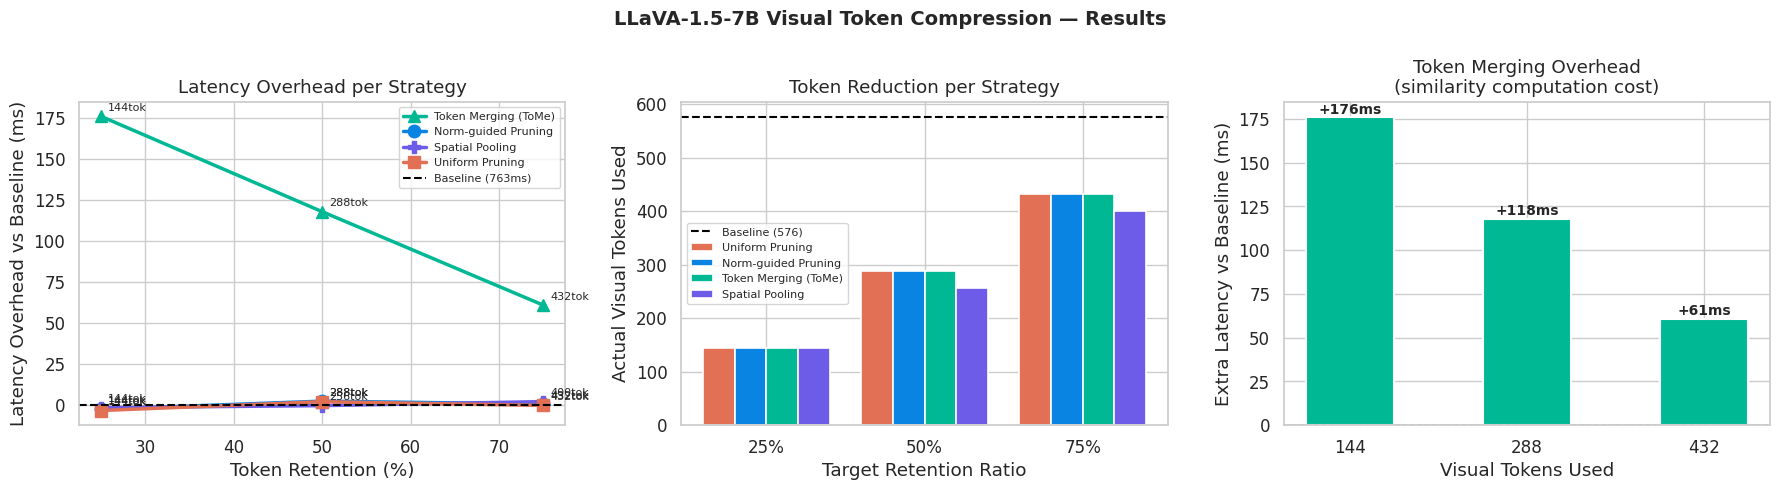

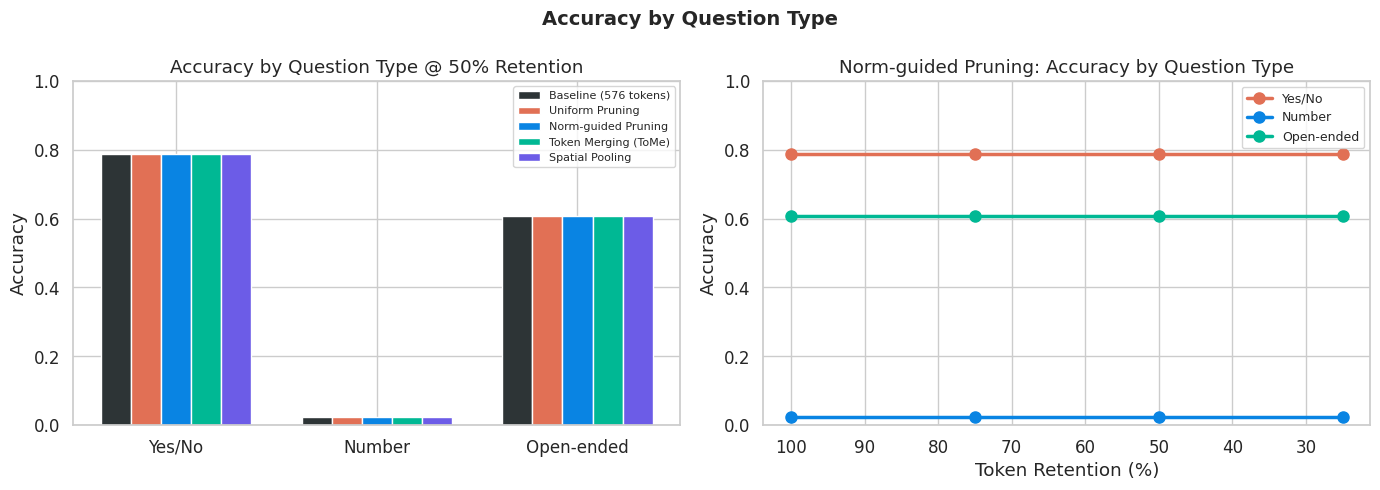

Figures saved.


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np

results_df = pd.read_csv(RESULTS_PATH)

COLORS  = {'baseline':'#2d3436','uniform':'#e17055',
           'norm':'#0984e3','merge':'#00b894','pool':'#6c5ce7'}
MARKERS = {'baseline':'D','uniform':'s','norm':'o','merge':'^','pool':'P'}
LABELS  = {
    'baseline': 'Baseline (576 tokens)',
    'uniform' : 'Uniform Pruning',
    'norm'    : 'Norm-guided Pruning',
    'merge'   : 'Token Merging (ToMe)',
    'pool'    : 'Spatial Pooling',
}

sns.set_theme(style='whitegrid', font_scale=1.1)

# ── Figure 1: Latency Overhead + Token Reduction ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('LLaVA-1.5-7B Visual Token Compression — Results', fontsize=14, fontweight='bold')

non_base     = results_df[results_df['strategy'] != 'baseline']
baseline_lat = results_df[results_df['strategy']=='baseline']['latency_ms'].values[0]

# Fig 1a: Latency overhead vs baseline
ax = axes[0]
for strat, grp in non_base.groupby('strategy'):
    grp      = grp.sort_values('keep_ratio')
    overhead = grp['latency_ms'] - baseline_lat
    ax.plot(grp['keep_ratio']*100, overhead,
            color=COLORS[strat], marker=MARKERS[strat],
            linewidth=2.5, markersize=9, label=LABELS[strat])
    for _, row in grp.iterrows():
        ax.annotate(f"{row['tokens_used']:.0f}tok",
                    (row['keep_ratio']*100, row['latency_ms']-baseline_lat),
                    textcoords='offset points', xytext=(5, 4), fontsize=8)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Baseline (763ms)')
ax.set_xlabel('Token Retention (%)')
ax.set_ylabel('Latency Overhead vs Baseline (ms)')
ax.set_title('Latency Overhead per Strategy')
ax.legend(fontsize=8)

# Fig 1b: Actual tokens used
ax       = axes[1]
ratio_order = [0.25, 0.50, 0.75]
strats   = ['uniform', 'norm', 'merge', 'pool']
x        = np.arange(len(ratio_order))
w        = 0.2
for i, strat in enumerate(strats):
    grp  = non_base[non_base['strategy']==strat].sort_values('keep_ratio')
    vals = grp['tokens_used'].values
    ax.bar(x + i*w, vals, w, label=LABELS[strat],
           color=COLORS[strat], edgecolor='white', linewidth=1.2)
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(['25%', '50%', '75%'])
ax.set_xlabel('Target Retention Ratio')
ax.set_ylabel('Actual Visual Tokens Used')
ax.set_title('Token Reduction per Strategy')
ax.axhline(576, color='black', linestyle='--', linewidth=1.5, label='Baseline (576)')
ax.legend(fontsize=8)

# Fig 1c: ToMe overhead
ax       = axes[2]
merge_df = non_base[non_base['strategy']=='merge'].sort_values('keep_ratio')
tokens   = merge_df['tokens_used'].values
overhead = merge_df['latency_ms'].values - baseline_lat
ax.bar(tokens.astype(int).astype(str), overhead,
       color='#00b894', edgecolor='white', linewidth=1.5, width=0.5)
for i, (tok, oh) in enumerate(zip(tokens, overhead)):
    ax.text(i, oh + 2, f'+{oh:.0f}ms', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Visual Tokens Used')
ax.set_ylabel('Extra Latency vs Baseline (ms)')
ax.set_title('Token Merging Overhead\n(similarity computation cost)')
ax.axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'results_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Accuracy by Question Type ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Accuracy by Question Type', fontsize=14, fontweight='bold')

q_types  = ['acc_yesno', 'acc_number', 'acc_other']
q_labels = ['Yes/No', 'Number', 'Open-ended']
x = np.arange(len(q_labels))
w = 0.15

half_df = results_df[
    (results_df['keep_ratio'].between(0.49, 0.51)) |
    (results_df['strategy'] == 'baseline')
].copy()
all_strats = ['baseline', 'uniform', 'norm', 'merge', 'pool']

ax = axes[0]
for i, strat in enumerate(all_strats):
    row  = half_df[half_df['strategy']==strat].iloc[0]
    vals = [row.get(qt) or 0 for qt in q_types]
    ax.bar(x + i*w, vals, w, label=LABELS[strat],
           color=COLORS[strat], edgecolor='white')
ax.set_xticks(x + w*2)
ax.set_xticklabels(q_labels)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Question Type @ 50% Retention')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.0)

ax       = axes[1]
base_row = results_df[results_df['strategy']=='baseline'].iloc[0]
norm_df  = results_df[results_df['strategy']=='norm'].sort_values('keep_ratio', ascending=False)
for qt, ql, color in zip(q_types, q_labels, ['#e17055','#0984e3','#00b894']):
    base_val = base_row.get(qt) or 0
    vals     = [base_val] + list(norm_df[qt].fillna(0).values)
    ratios   = [100, 75, 50, 25]
    ax.plot(ratios, vals, marker='o', linewidth=2.5,
            markersize=8, label=ql, color=color)
ax.set_xlabel('Token Retention (%)')
ax.set_ylabel('Accuracy')
ax.set_title('Norm-guided Pruning: Accuracy by Question Type')
ax.legend(fontsize=9)
ax.invert_xaxis()
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'results_by_type.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figures saved.')

## Section 7 — Demo

Visual comparison of all compression strategies on representative samples.
Green overlay = retained tokens, Red overlay = pruned tokens.

Processing: Yes/No — "Is this a creamy soup?"
Processing: Number — "How many photo's can you see?"
Processing: Open-ended — "Where is he looking?"


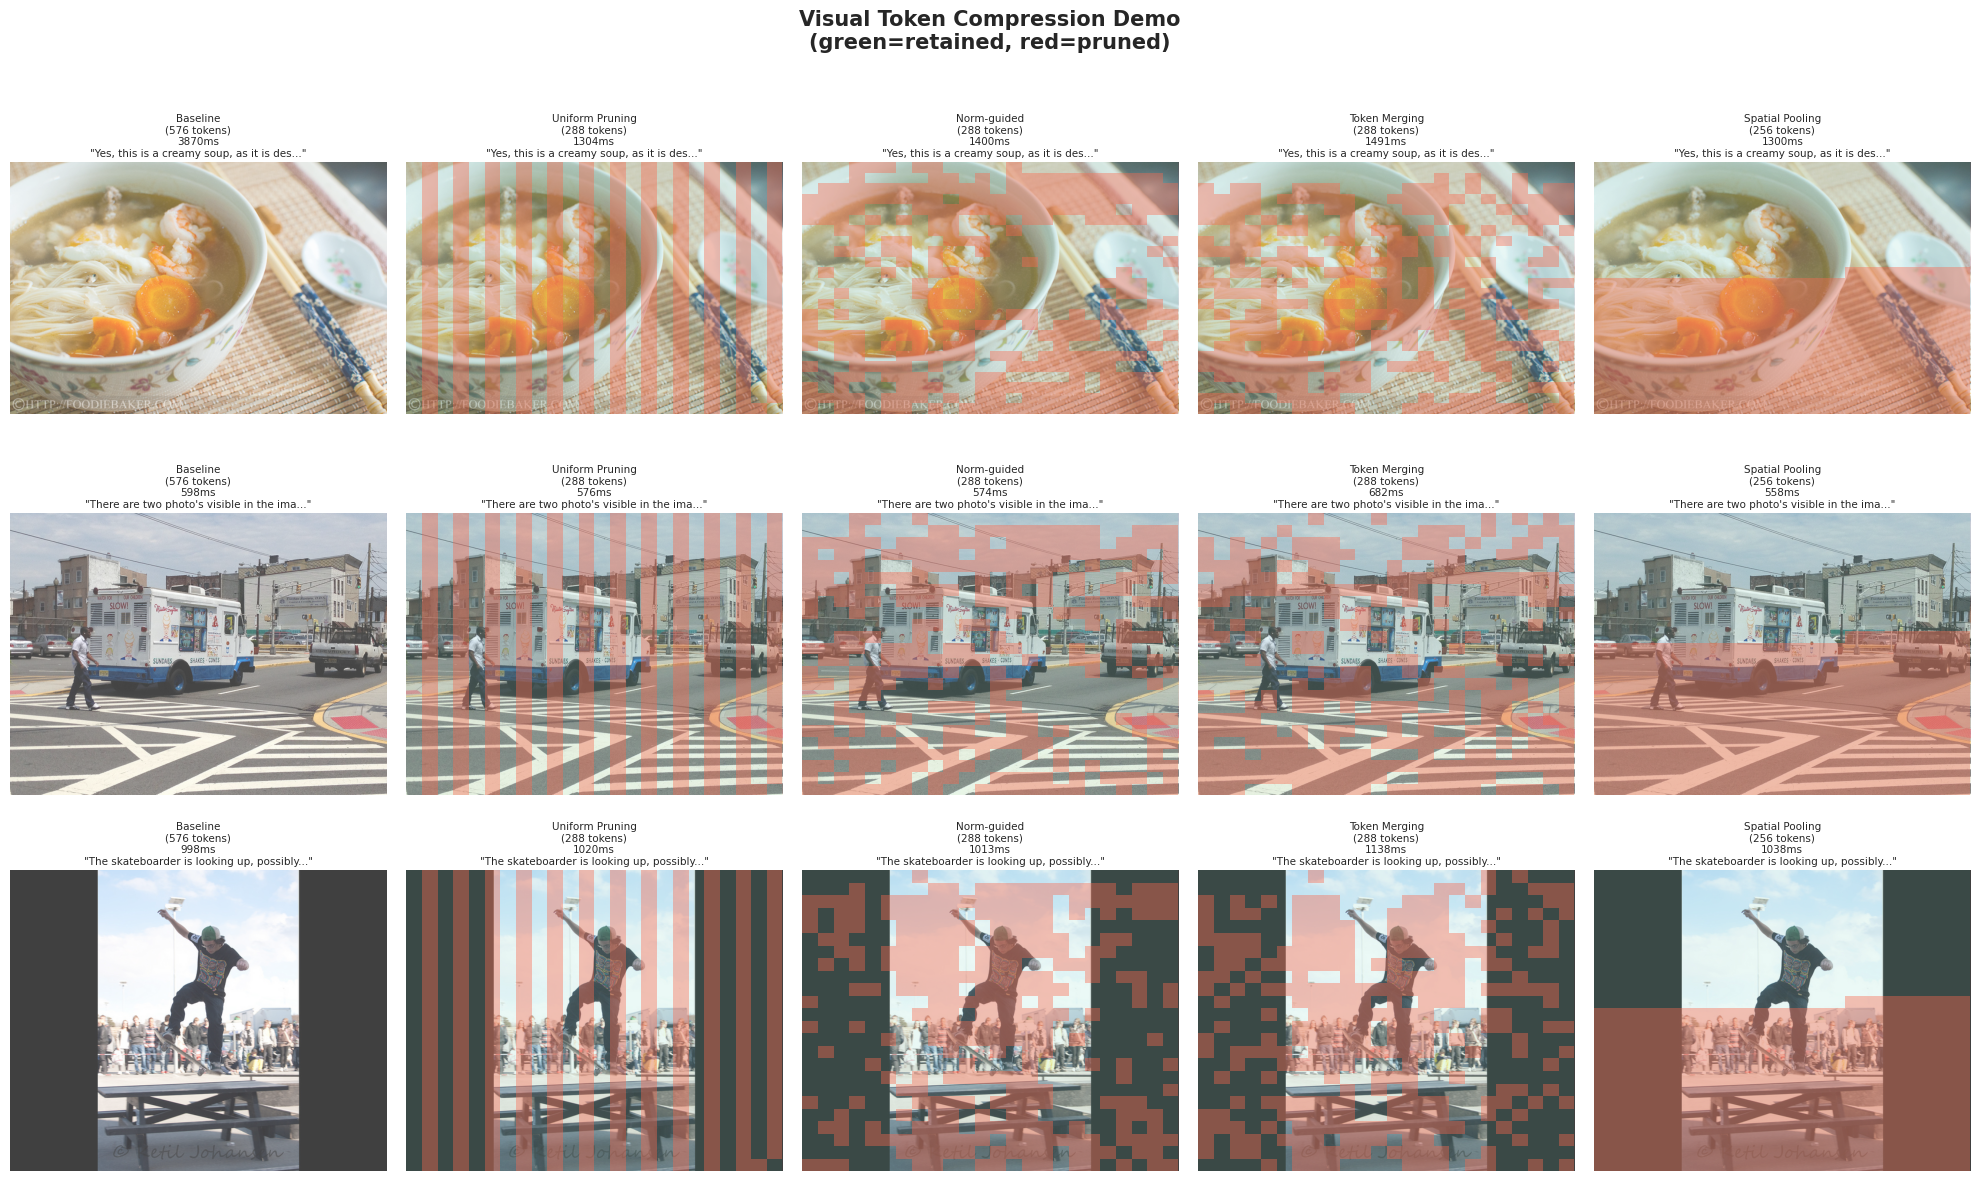

Saved: demo_full_fixed.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample_indices = {
    'Yes/No':     next(i for i, s in enumerate(samples) if s['answer_type'] == 'yes/no'),
    'Number':     next(i for i, s in enumerate(samples) if s['answer_type'] == 'number'),
    'Open-ended': next(i for i, s in enumerate(samples) if s['answer_type'] == 'other'),
}

strategies_to_show = [
    ('baseline', 1.0),
    ('uniform',  0.5),
    ('norm',     0.5),
    ('merge',    0.5),
    ('pool',     0.5),
]

strat_labels = {
    'baseline': 'Baseline\n(576 tokens)',
    'uniform' : 'Uniform Pruning\n(288 tokens)',
    'norm'    : 'Norm-guided\n(288 tokens)',
    'merge'   : 'Token Merging\n(288 tokens)',
    'pool'    : 'Spatial Pooling\n(256 tokens)',
}

def draw_token_grid(ax, image, kept_indices):
    grid_size = 24
    cell_w    = image.width  / grid_size
    cell_h    = image.height / grid_size
    kept_set  = set(kept_indices) if kept_indices else set()
    for idx in range(N_VISUAL):
        row   = idx // grid_size
        col   = idx % grid_size
        kept  = idx in kept_set
        color = '#00b894' if kept else '#e17055'
        alpha = 0.08 if kept else 0.45
        rect  = patches.Rectangle(
            (col * cell_w, row * cell_h), cell_w, cell_h,
            linewidth=0, facecolor=color, alpha=alpha
        )
        ax.add_patch(rect)

fig, axes = plt.subplots(
    len(sample_indices), len(strategies_to_show),
    figsize=(20, 12)
)
fig.suptitle('Visual Token Compression Demo\n(green=retained, red=pruned)',
             fontsize=15, fontweight='bold', y=1.01)

for row_idx, (qtype, sample_idx) in enumerate(sample_indices.items()):
    sample = samples[sample_idx]
    image  = sample['image'].convert('RGB')
    print(f'Processing: {qtype} — "{sample["question"]}"')

    for col_idx, (strat_name, ratio) in enumerate(strategies_to_show):
        fn = STRATEGIES[strat_name]
        pred, lat, _, n_tok, kept_idx = run_inference_single(
            sample, fn, ratio
        )
        ax = axes[row_idx][col_idx]
        ax.imshow(image, alpha=0.75)
        if strat_name != 'baseline' and kept_idx is not None:
            draw_token_grid(ax, image, kept_idx)
        short_pred = pred[:40] + '...' if len(pred) > 40 else pred
        ax.set_title(
            f'{strat_labels[strat_name]}\n{lat:.0f}ms\n"{short_pred}"',
            fontsize=7.5, pad=4
        )
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(
                f'{qtype}\nQ: {sample["question"][:30]}\nGT: {sample["gt_answer"]}',
                fontsize=8, rotation=0, ha='right', va='center', labelpad=80
            )

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'demo_full_fixed.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: demo_full_fixed.png')